## Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
###1.Exploratory Data Analysis (EDA):
###Loading the dataset:
df=pd.read_csv('monthly_milk_production.csv')

In [3]:
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [5]:
df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


In [6]:
df.shape

(168, 2)

In [7]:
df.size

336

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        168 non-null    datetime64[ns]
 1   Production  168 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.8 KB


In [9]:
###Check Missing Values:
df.isnull().sum()

Date          0
Production    0
dtype: int64

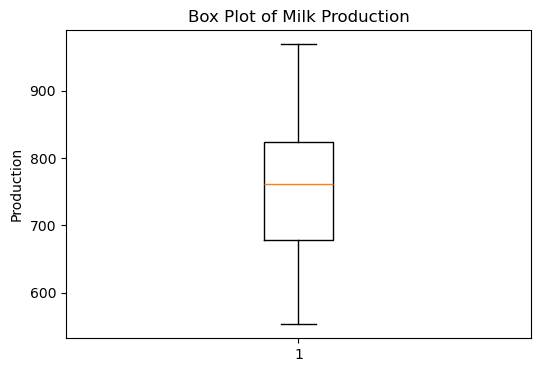

In [10]:
####Check Outliers/Visualize Anomalies:
plt.figure(figsize=(6, 4))
plt.boxplot(df["Production"])
plt.title("Box Plot of Milk Production")
plt.ylabel("Production")
plt.show()

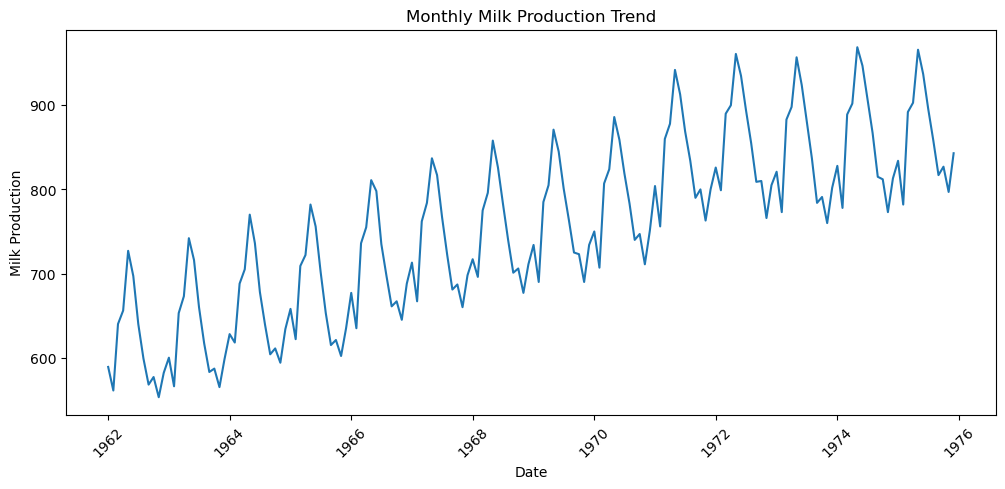

In [11]:
####Visualize Milk Production Trend:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Production"])
plt.title("Monthly Milk Production Trend")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.xticks(rotation=45)
plt.show()

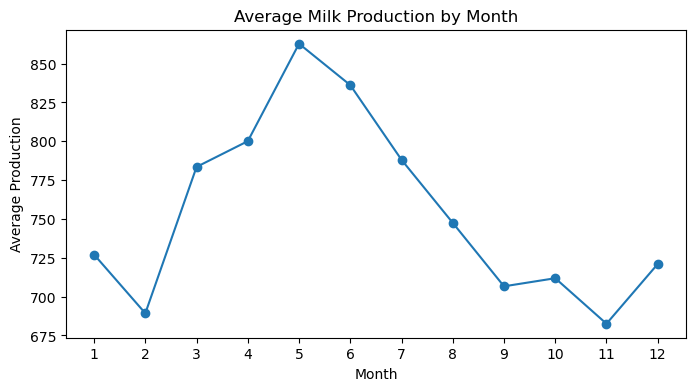

In [12]:
####Visualize Seasonality:
df["Month"] = df["Date"].dt.month
monthly_avg = df.groupby("Month")["Production"].mean()
plt.figure(figsize=(8, 4))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.show()

In [13]:
####Normalize the Data:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["Production_Scaled"] = scaler.fit_transform(
    df[["Production"]]
)
df[["Production", "Production_Scaled"]].head()

,Production,Production_Scaled
0,589,0.086538
1,561,0.019231
2,640,0.209135
3,656,0.247596
4,727,0.418269


## 1. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the monthly milk production data before building the forecasting models.

* **Trend and Seasonality:** A line plot was used to visualize monthly milk production over time and identify trends and seasonal patterns.
* **Anomalies and Outliers:** A box plot was used to check for unusual or extreme production values. No significant outliers were found.
* **Missing Values:** The dataset was checked using `isnull().sum()`, and no missing values were found.
* **Data Scaling:** The production values were normalized using `MinMaxScaler`, scaling them to a suitable range for RNN, LSTM, and GRU models.

    Overall, the EDA showed that the dataset was complete and suitable for further time-series forecasting.


In [14]:
###2.Data Preparation for Deep Learning
####Create Input-Output Sequences:
data = df["Production"].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data[:5]
window_size = 12
X = []
y = []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i])
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [15]:
###Split into Training, Validation and Test Sets:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (109, 12, 1)
Validation: (23, 12, 1)
Testing: (24, 12, 1)


## Reshape data for model input dimensions:
    Reshaping is already done during sequence creation, because X has the required shape (samples, 12, 1).

## 2. Data Preparation for Deep Learning

The scaled milk production data was converted into input-output sequences using a 12-month time window. The previous 12 months were used to predict the next month's production, resulting in 156 sequences. The data was then divided chronologically into 70% training, 15% validation, and 15% test sets. The input data was represented in the required three-dimensional format (samples, time steps, features), where 12 represents the monthly time steps and 1 represents the milk production feature. This format is suitable for training RNN, LSTM, and GRU models

In [16]:
####3.Model Building:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

In [17]:
####Basic RNN Model:
rnn_model = Sequential([
    SimpleRNN(50, activation="tanh", input_shape=(12, 1)),
    Dense(1)
])
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
###Train the RNN:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0317 - val_loss: 0.0166
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0130 - val_loss: 0.0131
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0089 - val_loss: 0.0068
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0067 - val_loss: 0.0112
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0048 - val_loss: 0.0051
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0035 - val_loss: 0.0065
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0028 - val_loss: 0.0049
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0026 - val_loss: 0.0048
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0024 - val_loss: 0.0040
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0023 - val_loss: 0.0050
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024 - val_loss: 0.0049
E

The Basic RNN learns patterns from the previous 12 months of milk production. It uses 50 neurons and the tanh activation function. Mean Squared Error (MSE) is used as the loss function and Adam is used as the optimizer.

In [19]:
###LSTM Model:
lstm_model = Sequential([
    LSTM(50, activation="tanh", input_shape=(12, 1)),
    Dense(1)
])
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
###Train the LSTM:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.1090 - val_loss: 0.1046
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0347 - val_loss: 0.0299
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0327 - val_loss: 0.0305
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0285 - val_loss: 0.0334
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0260 - val_loss: 0.0353
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0253 - val_loss: 0.0301
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0244 - val_loss: 0.0272
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0248 - val_loss: 0.0263
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0240 - val_loss: 0.0287
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0236 - val_loss: 0.0284
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0232 - val_loss: 0.0263
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0228 - val_loss: 0.0250
E

LSTM is designed to remember important information over longer time periods. It is useful for time-series data because it can learn long-term dependencies in milk production.

In [21]:
###GRU Model:
gru_model = Sequential([
    GRU(50, activation="tanh", input_shape=(12, 1)),
    Dense(1)
])
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
##Train the GRU:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.1917 - val_loss: 0.2864
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0673 - val_loss: 0.0813
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0268 - val_loss: 0.0259
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0317 - val_loss: 0.0242
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0279 - val_loss: 0.0321
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0237 - val_loss: 0.0424
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0237 - val_loss: 0.0451
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0232 - val_loss: 0.0401
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0221 - val_loss: 0.0332
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0218 - val_loss: 0.0285
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0212 - val_loss: 0.0288
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0206 - val_loss: 0.0314
E

GRU is another recurrent neural network architecture. It is simpler than LSTM but can also learn important patterns and dependencies in time-series data.

In [23]:
###Hyperparameter Tuning:
###Simple LSTM Tuning:
units_list = [32, 50, 64]
tuning_results = []
for units in units_list:
    model = Sequential([
        LSTM(units, activation="tanh", input_shape=(12, 1)),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=16,
        verbose=1
    )
    best_val_loss = min(history.history["val_loss"])
    tuning_results.append([units, best_val_loss])
print(tuning_results)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.2034 - val_loss: 0.3745
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1165 - val_loss: 0.1948
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0546 - val_loss: 0.0630
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0285 - val_loss: 0.0259
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0323 - val_loss: 0.0256
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0264 - val_loss: 0.0351
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0263 - val_loss: 0.0426
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0262 - val_loss: 0.0343
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0250 - val_loss: 0.0293
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0247 - val_loss: 0.0287
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0245 - val_loss: 0.0279
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0241 - val_loss: 0.0292
E

##  Hyperparameter Tuning:
        Different numbers of LSTM units (32, 50, and 64) were tested while keeping the other parameters fixed. The validation loss was compared, and the configuration with the lowest validation loss was selected.

In [24]:
####loss functions and optimizers:
##RNN:
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)
##LSTM:
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)
###GRU:
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

## Loss Function and Optimizer:
Mean Squared Error (MSE) was used as the loss function because milk production forecasting is a regression problem. The Adam optimizer with a learning rate of 0.001 was used to update the model weights and minimize prediction error. The same settings were used for the RNN, LSTM, and GRU models.

In [25]:
# Make predictions using all three models

rnn_pred = rnn_model.predict(X_test, verbose=0)
lstm_pred = lstm_model.predict(X_test, verbose=0)
gru_pred = gru_model.predict(X_test, verbose=0)
print("Predictions completed.")

Predictions completed.


In [26]:
### Convert predictions back to original scale:
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
y_actual = scaler.inverse_transform(y_test)
print("RNN predictions:", rnn_pred[:5])
print("LSTM predictions:", lstm_pred[:5])
print("GRU predictions:", gru_pred[:5])
print("Actual values:", y_actual[:5])

RNN predictions: [[830.68384]
 [805.6427 ]
 [874.06116]
 [889.69824]
 [939.59375]]
LSTM predictions: [[786.5063 ]
 [809.98694]
 [838.9361 ]
 [879.5403 ]
 [907.90515]]
GRU predictions: [[819.715  ]
 [852.0072 ]
 [813.79364]
 [876.18176]
 [908.32935]]
Actual values: [[828.]
 [778.]
 [889.]
 [902.]
 [969.]]


In [27]:
###Calculate RMSE, MAE and MAPE:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return rmse, mae, mape
rnn_rmse, rnn_mae, rnn_mape = calculate_metrics(y_actual, rnn_pred)
lstm_rmse, lstm_mae, lstm_mape = calculate_metrics(y_actual, lstm_pred)
gru_rmse, gru_mae, gru_mape = calculate_metrics(y_actual, gru_pred)
print("RNN  - RMSE:", rnn_rmse, "MAE:", rnn_mae, "MAPE:", rnn_mape)
print("LSTM - RMSE:", lstm_rmse, "MAE:", lstm_mae, "MAPE:", lstm_mape)
print("GRU  - RMSE:", gru_rmse, "MAE:", gru_mae, "MAPE:", gru_mape)

RNN  - RMSE: 16.333963855033915 MAE: 13.214864095052073 MAPE: 1.5198675648526214
LSTM - RMSE: 32.81617643109127 MAE: 27.632268269856763 MAPE: 3.18215575604459
GRU  - RMSE: 38.10095116954862 MAE: 28.829714457194 MAPE: 3.3687106769237967


In [28]:
###Compare RNN, LSTM and GRU:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "MAPE (%)": [rnn_mape, lstm_mape, gru_mape]
})
print(results)

  Model       RMSE        MAE  MAPE (%)
0   RNN  16.333964  13.214864  1.519868
1  LSTM  32.816176  27.632268  3.182156
2   GRU  38.100951  28.829714  3.368711


## Model Comparison:
        The RNN, LSTM, and GRU models were compared using RMSE, MAE, and MAPE. The RNN model achieved the lowest values for all three metrics and was therefore selected as the best-performing model.

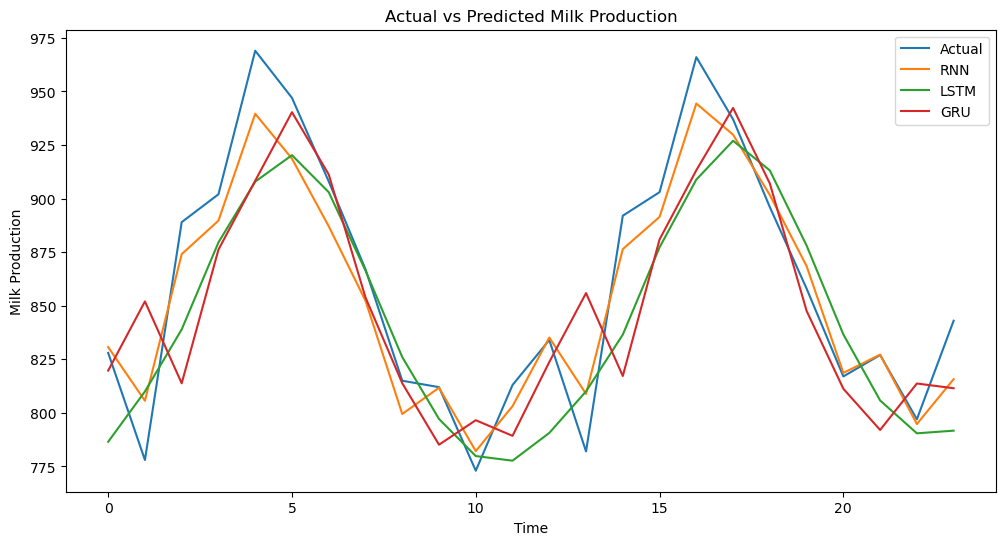

In [30]:
####Plot Actual vs Predicted Values:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(y_actual, label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

## 4.Model Evaluation:
The trained RNN, LSTM, and GRU models were evaluated using the test dataset. Predictions were converted back to the original milk production scale using inverse scaling. RMSE, MAE, and MAPE were calculated to measure forecasting accuracy. Lower values of these metrics indicate better performance. Actual and predicted milk production values were also plotted to visually compare the models. Finally, the performance of RNN, LSTM, and GRU was compared using the evaluation metrics, and the model with the lowest errors was considered the best-performing model.

In [36]:
##5.Prediction and Visualization:
##Forecast the next 12 months:
# Use the best-performing model
best_model = rnn_model
# Start with the last 12 months
last_12 = scaled_data[-12:].reshape(1, 12, 1)
future_predictions = []
# Forecast next 12 months
for i in range(12):
    next_value = best_model.predict(last_12, verbose=0)
    future_predictions.append(next_value[0, 0])
    # Update the input window
    last_12 = np.append(last_12[:, 1:, :], 
                        next_value.reshape(1, 1, 1), axis=1)
# Convert predictions back to original scale
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)
print("Next 12 Months Forecast:")
print(future_predictions)

Next 12 Months Forecast:
[[844.4304 ]
 [813.2831 ]
 [882.48517]
 [891.5425 ]
 [938.07806]
 [919.6716 ]
 [894.42377]
 [865.3457 ]
 [827.521  ]
 [840.9481 ]
 [816.072  ]
 [842.6584 ]]


In [37]:
##Create future dates:
future_dates = pd.date_range(
    start=df["Date"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
print(future_dates)

DatetimeIndex(['1976-01-01', '1976-02-01', '1976-03-01', '1976-04-01',
               '1976-05-01', '1976-06-01', '1976-07-01', '1976-08-01',
               '1976-09-01', '1976-10-01', '1976-11-01', '1976-12-01'],
              dtype='datetime64[ns]', freq='MS')


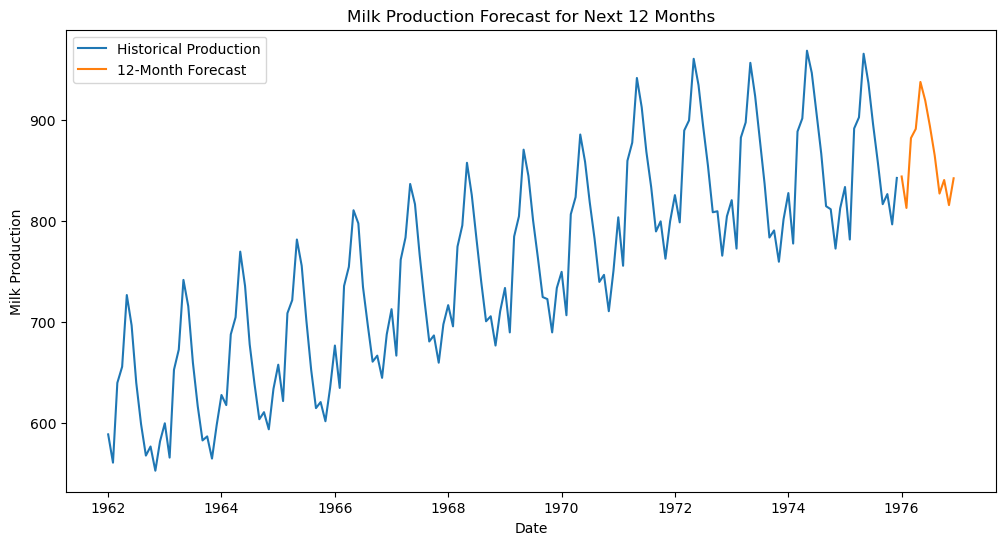

In [38]:
##Visualize the forecast:
plt.figure(figsize=(12, 6))
# Historical production
plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)
# Future forecast
plt.plot(
    future_dates,
    future_predictions.flatten(),
    label="12-Month Forecast"
)
plt.title("Milk Production Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

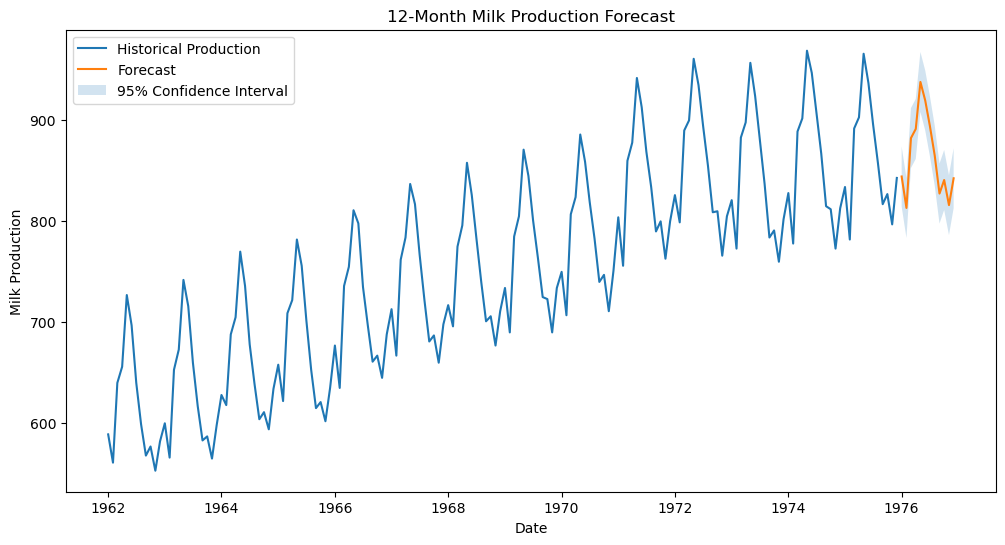

In [39]:
###Confidence Interval:
# Calculate prediction errors from the best model
best_test_pred = rnn_pred.flatten()
actual = y_actual.flatten()
errors = actual - best_test_pred
error_std = np.std(errors)
# 95% confidence interval
lower_bound = future_predictions.flatten() - 1.96 * error_std
upper_bound = future_predictions.flatten() + 1.96 * error_std
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Production"], label="Historical Production")
plt.plot(future_dates, future_predictions.flatten(), label="Forecast")
plt.fill_between(
    future_dates,
    lower_bound,
    upper_bound,
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.title("12-Month Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

 ## Prediction and Visualization:

        The best-performing RNN model was used to forecast milk production for the next 12 months. The predicted values were converted back to the original production scale using inverse scaling. A line plot was created to visualize the historical production and future forecast. A 95% confidence interval was also included to represent the uncertainty in the predictions.

In [35]:
### 6. Business Insights
# Create forecast table using the 12-month predictions already generated
forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecast_Milk_Production': future_predictions.flatten()
})
print(forecast_df)
# Business summary statistics
print('Average Production :', round(forecast_df['Forecast_Milk_Production'].mean(), 2))
print('Maximum Production :', round(forecast_df['Forecast_Milk_Production'].max(), 2))
print('Minimum Production :', round(forecast_df['Forecast_Milk_Production'].min(), 2))

        Month  Forecast_Milk_Production
0  1976-01-01                807.231262
1  1976-02-01                812.563843
2  1976-03-01                845.140869
3  1976-04-01                867.006104
4  1976-05-01                889.486328
5  1976-06-01                890.948914
6  1976-07-01                880.213501
7  1976-08-01                862.199585
8  1976-09-01                842.411377
9  1976-10-01                830.538025
10 1976-11-01                816.145081
11 1976-12-01                814.777954
Average Production : 846.56
Maximum Production : 890.95
Minimum Production : 807.23


## Business Insights: 
    
        The RNN-based forecasted milk production values help the dairy business estimate future supply for the next 12 months. The average production indicates expected normal production levels, while maximum and minimum values highlight seasonal variations. Management can use these forecasts for storage planning, transportation scheduling, labor allocation, inventory management, budgeting, and supply-chain planning. Forecasting helps reduce wastage and improve operational efficiency.